# 26 — Combined (pooled) de-leakage grid

Companion to notebook 23's per-dataset disjoint-bin grid.
Splitting by dataset leaves several bins with single-digit n
(coach420 especially), so here the four screening datasets —
coach420, scpdb, pdbbind2020, holo4k — are pooled into ONE
population per bin instead of one line per dataset, trading
per-dataset visibility for larger, less noisy per-bin samples.

Pooling raises one real complication: the same PDB complex
(same pdb_id + bound-ligand code) is sometimes curated into
more than one of these datasets, so naive concatenation
double- or triple-counts it. Every bin below is built on the
**deduped** pool: for a (pdb_id, ligand) pair spanning more
than one dataset, keep only the copy from the first dataset in
`DATASET_PRIORITY = [coach420, scpdb, pdbbind2020, holo4k]`;
drop the rest. Repeats of the same pair *within* one dataset
are left alone — that's the dataset's own modelling choice,
not a pooling artifact. (A diagnostic below shows the raw-vs-
deduped gap is small — a separate "all data points" line
wasn't worth the clutter, so this notebook shows deduped only.)

Same disjoint-bin philosophy as notebook 23's grid (a bin's
metric shouldn't be diluted by cumulative pooling — see that
notebook for the full argument), but with coarser bins, each
row going lenient -> strict left to right. Tick labels spell out
the exact interval each bin covers, matching the manuscript's own
bracket convention:

1. **SI% bins** partition the *whole* deduped dataset: "same PDB"
   (pdb_id literally in the training union — the memorized
   subset itself, not "duplicates removed") → >70% → (50,70]% →
   (30,50]% → <=30% (novel), the last 4 computed on the remaining
   (pdb_id NOT in training) pockets by receptor SI% to the
   nearest training receptor.
2. **Ligand-frequency bins**, within the <=30% (novel) bin:
   >=100 → [25,99] → [5,24] → [1,4] → 0 (absent).
3. **Novelty bins**, within the 0 (absent) bin: [0.9,1.0] →
   [0.7,0.9) → [0.5,0.7) → [0.3,0.5) → <0.3 (novel) — the
   original 0.9-<1.0 and =1.0 (identical) bins are merged into
   one [0.9,1.0] bin (both were too thin on their own).

Each row has a dashed reference line: row 1's is the whole
(unfiltered) dataset (`combined_deleakage_analysis.l0_metrics`)
— by construction a weighted average of "same PDB" (memorized,
very high) and the rest, so it sits *below* "same PDB" and
*above* the less-memorized bins, which is the expected
signature of leakage, not a bug. Rows 2/3's dashed line is that
row's own "all" bin — exactly the previous row's strictest bin
— shown only as a line (not plotted as a redundant point, since
that would just repeat the dashed value). Axes are shared per
column (`sharey`), so all three rows read off the same scale.

Every column also has a dotted **random-chance** reference line,
closed-form given the library size (n_mols=48,999 CCD compounds):
EF1%=1 by definition; top-1% = 1/n_mols (~0.002%, indistinguishable
from 0 at this scale); median rank = (n_mols+1)/2 = 24,500 — far
above the plotted range, but the log-scale median-rank column
still shows it cleanly without squashing the real data.

Two tables follow the grid: pocket-ligand-pair counts per bin, and
the actual EF1% / top-1% / median rank per bin — both also report
the whole-dataset (L0) reference alongside the SI% bins.

All heavy logic lives in `scripts/combined_deleakage_analysis.py`
and `scripts/combined_manuscript_figures.py`; regenerate this
notebook via `scripts/build_combined_deleakage_notebook.py`.

## Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().parent / 'DATA' / 'natural_ligands'
sys.path.insert(0, str(Path.cwd() / 'natural_ligands_scripts'))

import ligand_frequency_analysis as lf
import ligand_similarity_analysis as ls
import combined_deleakage_analysis as cd
import combined_manuscript_figures as cmf

## How much does cross-dataset duplication matter?

Rows dropped by dedup, per dataset (a dataset only loses rows
when a higher-priority dataset already carries the same
(pdb_id, ligand) pair).

In [4]:
pp = cd.load_pooled()
n_mols = lf.lib_size()
deduped = cd.dedup_cross_dataset(pp)
print(f'pooled rows: {len(pp)}  deduped rows: {len(deduped)}  '
      f'dropped: {len(pp) - len(deduped)}')
dropped = pp.loc[pp.index.difference(deduped.index)]
dropped.groupby('dataset').size()

pooled rows: 17305  deduped rows: 15640  dropped: 1665


dataset
holo4k         1341
pdbbind2020     268
scpdb            56
dtype: int64

## Combined grid

training ligands with a fingerprint: 22774 (of 23023 unique training codes)


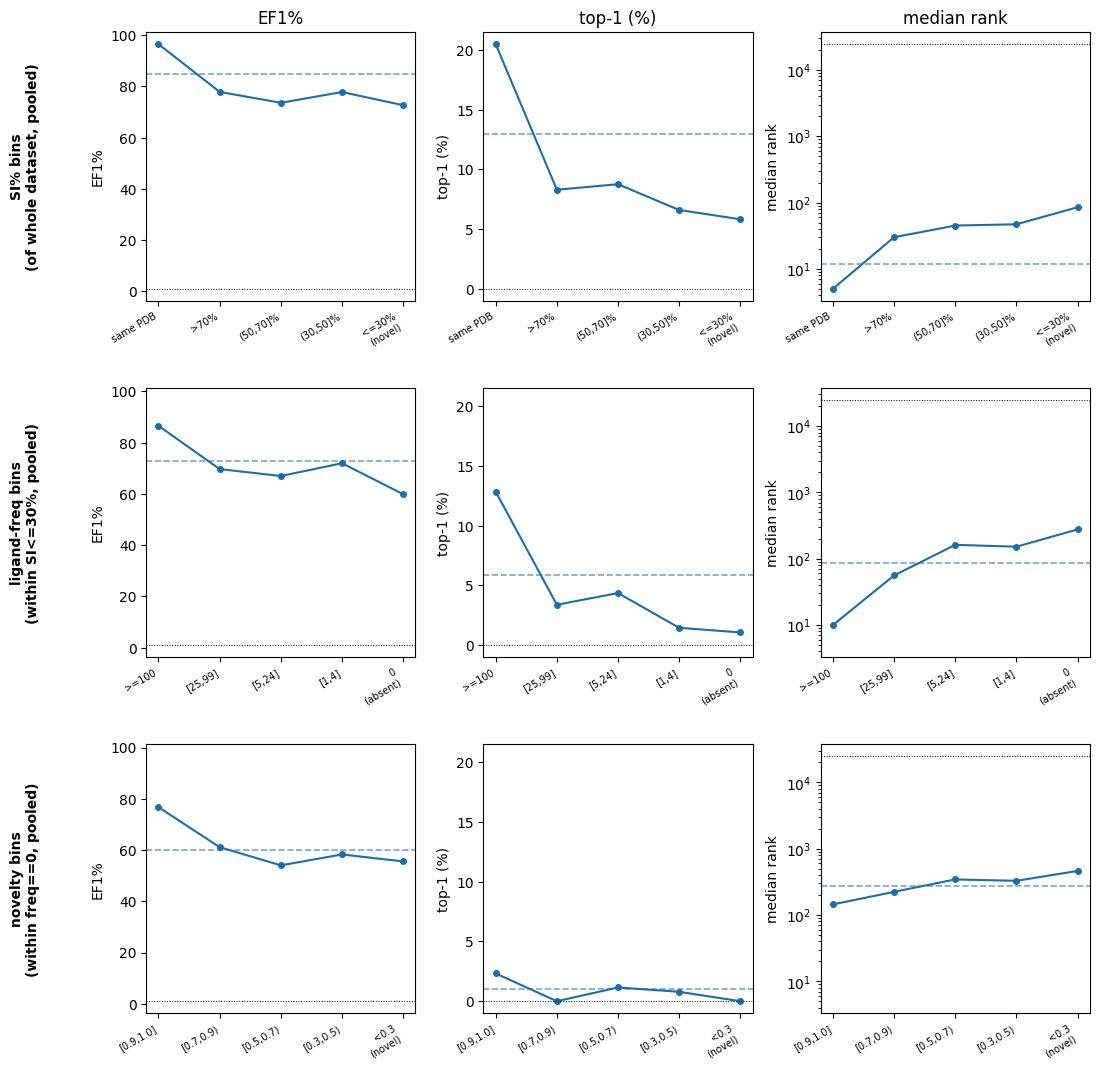

In [6]:
si_bins = cd.build_si_bins_combined(n_mols, pp)
freq_bins = cd.build_freq_bins_combined(n_mols, pp)
fp_map = ls.code_to_fp()
pp_ts = ls.annotate_nn_ts(pp, fp_map=fp_map)
ts_bins = cd.build_ts_bins_combined(n_mols, pp_ts)
l0 = cd.l0_metrics(n_mols, pp)
fig = cmf.plot_grid_combined(si_bins, freq_bins, ts_bins, l0, n_mols)
plt.show()

### How many pocket-ligand pairs fall in each bin?

n_in_library (evaluable pockets, deduped) in every disjoint
bin of the three rows above — same x-axis order as the grid.

In [5]:
t1, t2, t3 = cmf.pocket_counts_combined(si_bins, freq_bins, ts_bins, l0)
print('SI% bins (of whole dataset)'); display(t1)
print('ligand-frequency bins (within SI<=30%)'); display(t2)
print('novelty bins (within freq==0)'); display(t3)

NameError: name 'ts_bins' is not defined

### What's the actual performance per bin?

EF1% / top-1% / median rank (deduped), same bins as the counts
table above — includes the whole-dataset (L0) reference for row 1.

In [ ]:
p1, p2, p3 = cmf.performance_combined(si_bins, freq_bins, ts_bins, l0)
print('SI% bins (of whole dataset)'); display(p1)
print('ligand-frequency bins (within SI<=30%)'); display(p2)
print('novelty bins (within freq==0)'); display(p3)